In the name of God

Seyed Mani Mirshabani 810801080

# M³TrustEval-XQuAD

 ## Modular Multilingual Trustworthiness Evaluation of a HuggingFace LLM

### Course Project: Large Language Models

---

##1. Project Summary

In this project, you will evaluate a single HuggingFace instruction-tuned language model on a real multilingual question-answering dataset.

The project focuses on five advanced LLM topics:

1. **Evaluation**
2. **Interpretability**
3. **Bias / Ethics**
4. **Modularity**
5. **Multilinguality**

The key idea is that LLM evaluation should not be limited to exact answer accuracy.  
A trustworthy evaluation should also ask:

- Does the model answer correctly?
- Is the explanation grounded in the given context?
- Does a modular verifier improve the answer?
- Does the model perform equally well across languages?
- Are there language-based performance disparities that raise fairness and ethical concerns?

---


## 2. Dataset and Model

### Dataset

We use **XQuAD** from HuggingFace:

- Dataset: `google/xquad`
- Task: Cross-lingual extractive question answering
- Languages used in this notebook: English, Arabic, German, Spanish, Turkish

XQuAD is useful here because the same QA examples are translated across multiple languages.  
This allows us to compare the same model across languages in a controlled way.

### Model

We use exactly one HuggingFace model:

- Model: `Qwen/Qwen2.5-0.5B-Instruct`

This is intentionally a small model so that the notebook can run on limited GPU resources.


## 3. Reference Papers and Links

This project is inspired by the following papers and resources.


### Main Evaluation Reference

**HELM: Holistic Evaluation of Language Models**  
Link: https://arxiv.org/abs/2211.09110

HELM motivates the idea that language models should be evaluated across multiple metrics, not just accuracy.

Paper Summary:

In this paper the authors suggest that LLMs shouldn't only be tested on small tasks and using one metric, so we can better understand their capabilities, limitations and risk.

They suggest HELM, a multi-metric benchmark framework that is designed to evaluate LMs across a wire range of scenarios, measuing not only the accuracy but other factors such as robustness, fairness and toxicity simultaniously.


### Trustworthiness Reference

**DecodingTrust: A Comprehensive Assessment of Trustworthiness in GPT Models**  
Link: https://arxiv.org/abs/2306.11698

DecodingTrust motivates the trustworthiness perspective, including fairness, robustness, ethics, privacy, and bias.

Paper Summary:

The focus of DecodingTrust paper is to deeply analyse the trustworthiness of GPD models. They designed a comprehensive benchmark to expose the vulnerability in GPT models by testing their behaiviours acroos eight dimensions: Toxicity, Stereotype Bias, Adversarial Robustness, Out-of-Distribution Robustness, Privacy, Machine Ehics, Fairness.

### Modularity / Self-Consistency Reference

**SelfCheckGPT: Zero-Resource Black-Box Hallucination Detection for Generative LLMs**  
Link: https://arxiv.org/abs/2303.08896

SelfCheckGPT motivates checking model outputs through consistency and verification.

Paper Summary:

LLMs confidently hallucinate false information. Detecting these can be difficult, especially if we don't have access to the internal probabilities of the model. This paper proposes a zero-resource technique for detecting hallucinations in black box models. Instead of comparing the generated text agains factual texts (such as wikipeadia or other databases), they generate multiple responses to a prompt and measures the consistency between them, under the assumption that if the model actually knows the informaiton and isn't hallucinating, its answers should be consistent so if it isn't, it's most likely hallucinating.

### Dataset Reference


**XQuAD: Cross-lingual Question Answering Dataset**  
HuggingFace: https://huggingface.co/datasets/google/xquad  
GitHub: https://github.com/google-deepmind/xquad

### Model Reference






**Qwen2.5-0.5B-Instruct**  
HuggingFace: https://huggingface.co/Qwen/Qwen2.5-0.5B-Instruct


## 4. Formal Project Statement

### Goal

Build a multilingual and modular evaluation framework for a HuggingFace LLM using the XQuAD dataset.


### Required Tasks

Students must:

1. Load the XQuAD dataset from HuggingFace.
2. Select a small multilingual subset from multiple languages.
3. Load one HuggingFace instruction-tuned model.
4. Run a **direct answering baseline**.
5. Run a **modular pipeline** consisting of:
   - generator
   - verifier
   - reviser
6. Compute answer quality metrics:
   - Exact Match
   - Token-level F1
7. Compute interpretability / faithfulness metrics:
   - whether the evidence appears in the context
   - whether the explanation is grounded in the context
8. Compute multilingual fairness metrics:
   - per-language performance
   - English vs. non-English gap
   - worst-language performance
   - language performance disparity
9. Compare the direct and modular systems.
10. Write a short discussion about bias, ethics, limitations, and possible improvements.

### Final Deliverables

Students should submit:

- completed notebook,
- generated CSV files,
- plots,
- final written analysis.

### Important Rule

Use only one LLM for generation and verification:

`Qwen/Qwen2.5-0.5B-Instruct`

## 5. Expected Research Questions



Your final report should answer:

1. Does the modular pipeline improve performance over the direct baseline?
2. Does the verifier improve explanation faithfulness?
3. Which language has the lowest performance?
4. Is there a large performance gap between English and non-English languages?
5. Can cross-lingual performance disparity be considered a form of language bias?
6. What are the ethical implications of deploying a model that performs much better in some languages than others?
7. What are the limitations of using the same model as both generator and verifier?
8. How could this project be extended to become a stronger research study?


## 6. Install Required Libraries



Run this cell in Colab, Kaggle, or a fresh local environment.

Recommended runtime:

- GPU enabled
- Internet enabled


In [1]:
# Run this cell to install the required libraries.
!pip -q install datasets transformers accelerate torch pandas numpy matplotlib tqdm rapidfuzz tabulate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 44.7 MB/s eta 0:00:00


## 7. Imports and Configuration

This notebook intentionally uses only one HuggingFace LLM.

You may reduce `N_EXAMPLES_PER_LANGUAGE` for quick debugging.  
For the final run, use a larger number if your GPU allows it.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import json
import re
from tqdm import tqdm
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForCausalLM
from rapidfuzz import fuzz
from tabulate import tabulate

# TODO: import the required libraries and define the configuration variables.
# Required variables:
# - MODEL_ID
# - DATASET_ID
# - LANG_CONFIGS
# - N_EXAMPLES_PER_LANGUAGE
# - MAX_CONTEXT_CHARS
# - MAX_NEW_TOKENS

MODEL_ID = "Qwen/Qwen2.5-0.5B-Instruct"
DATASET_ID = "google/xquad"
LANG_CONFIGS = ["xquad.en", "xquad.ar", "xquad.de", "xquad.es", "xquad.tr"]
N_EXAMPLES_PER_LANGUAGE = 100
MAX_CONTEXT_CHARS = 2000
MAX_NEW_TOKENS = 512

  ## 8. Load the XQuAD Dataset

    We load the same dataset in several languages.  
    Then we keep examples that have matching IDs across languages, so that the same underlying QA item can be compared cross-lingually.

In [3]:
  # TODO:
# 1. Load XQuAD for each language in LANG_CONFIGS.
# 2. Extract the first gold answer from the answers field.
# 3. Keep examples with common IDs across languages.
# 4. Return a DataFrame with:
#    id, lang, title, context, question, gold_answer

def load_and_align_xquad():
    all_language_data = {}
    id_sets = []

    for lang in LANG_CONFIGS:
        subset = load_dataset(DATASET_ID, name=lang, split="validation")

        lang_records = {}
        for example in subset:
            gold_answer = example["answers"]["text"][0] if example["answers"]["text"] else ""
            lang_records[example["id"]] = {
                "id": example["id"],
                "lang": lang,
                "title": example.get("title", ""),
                "context": example["context"],
                "question": example["question"],
                "gold_answer": gold_answer
            }

        all_language_data[lang] = lang_records
        id_sets.append(set(lang_records.keys()))

    common_ids = set.intersection(*id_sets)
    selected_ids = list(common_ids)[:N_EXAMPLES_PER_LANGUAGE]

    final_records = []
    for lang in LANG_CONFIGS:
        for q_id in selected_ids:
            final_records.append(all_language_data[lang][q_id])

    return pd.DataFrame(final_records)

xquad_df = load_and_align_xquad()

README.md:   0%|          | 0.00/15.6k [00:00<?, ?B/s]

xquad.en/validation-00000-of-00001.parqu(…):   0%|          | 0.00/212k [00:00<?, ?B/s]

Generating validation split:   0%|          | 0/1190 [00:00<?, ? examples/s]

xquad.ar/validation-00000-of-00001.parqu(…):   0%|          | 0.00/263k [00:00<?, ?B/s]

Generating validation split:   0%|          | 0/1190 [00:00<?, ? examples/s]

...

Generating validation split:   0%|          | 0/1190 [00:00<?, ? examples/s]

xquad.es/validation-00000-of-00001.parqu(…):   0%|          | 0.00/237k [00:00<?, ?B/s]

Generating validation split:   0%|          | 0/1190 [00:00<?, ? examples/s]

xquad.tr/validation-00000-of-00001.parqu(…):   0%|          | 0.00/228k [00:00<?, ?B/s]

Generating validation split:   0%|          | 0/1190 [00:00<?, ? examples/s]

## 9. Load the HuggingFace Model

This notebook uses only one model:

`Qwen/Qwen2.5-0.5B-Instruct`

The same model is used for:

- direct answering,
- answer generation,
- verification,
- revision.

This makes the project simple and reproducible, but it also creates an important limitation: the verifier may share the same weaknesses as the generator.


In [4]:
# TODO:
# Load the tokenizer and model from MODEL_ID using HuggingFace Transformers.
# Recommended:
# - AutoTokenizer.from_pretrained
# - AutoModelForCausalLM.from_pretrained
# - device_map="auto"

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
model = AutoModelForCausalLM.from_pretrained(MODEL_ID, device_map="auto")

config.json:   0%|          | 0.00/659 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/988M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

## 10. Helper Functions for Text Normalization and JSON Parsing

The model is asked to return JSON, but small LLMs may not always produce perfect JSON.  
The functions below make the evaluation more robust.

In [5]:
import collections
import json
import re

# TODO:
# Implement helper functions:
# - extract_json
# - normalize_answer
# - token_f1
# - exact_match
# - fuzzy_match

def extract_json(text):
    try:
        start_idx = text.find('{')
        end_idx = text.rfind('}')
        if start_idx != -1 and end_idx != -1:
            json_str = text[start_idx : end_idx + 1]
            return json.loads(json_str)
        return {}
    except:
        return {}

def extract_json(text):
    try:
        start_idx = text.find('{')
        end_idx = text.rfind('}')
        if start_idx != -1 and end_idx != -1:
            json_str = text[start_idx : end_idx + 1]
            return json.loads(json_str)
        return {}
    except:
        return {}

def parse_verifier_output(text):
    text_lower = text.lower()

    match_bool = re.search(r'"supported"\s*:\s*"?([Tt]rue|[Ff]alse)"?', text)
    if match_bool:
        is_supported = match_bool.group(1).lower() == 'true'
    else:
        is_supported = 'false' not in text_lower

    match_reason = re.search(r'"reason"\s*:\s*"([^"]+)"', text)
    if match_reason:
        reason = match_reason.group(1)
    else:
        reason = "The context does not fully support the answer."

    return is_supported, reason

def parse_reviser_output(text, original_answer):
    match = re.search(r'"answer"\s*:\s*"([^"]+)"', text)
    if match:
        return match.group(1)

    clean_text = text.replace('{', '').replace('}', '').replace('"answer":', '').replace('\n', ' ').strip()
    if clean_text and len(clean_text) < 200:
        return clean_text

    return original_answer

def normalize_answer(s):
    if not isinstance(s, str):
        return ""

    s = s.lower()

    s = re.sub(r'[^\w\s]', '', s)

    s = re.sub(r'\b(a|an|the)\b', '', s)

    return s.strip()

def exact_match(prediction, ground_truth):
    norm_pred = normalize_answer(prediction)
    norm_truth = normalize_answer(ground_truth)
    return norm_pred == norm_truth

def token_f1(prediction, ground_truth):
    pred_tokens = normalize_answer(prediction).split()
    truth_tokens = normalize_answer(ground_truth).split()

    common = collections.Counter(pred_tokens) & collections.Counter(truth_tokens)
    num_same = sum(common.values())

    if len(pred_tokens) == 0 or len(truth_tokens) == 0:
        return 1.0 if pred_tokens == truth_tokens else 0.0

    if num_same == 0:
        return 0.0

    precision = num_same / len(pred_tokens)
    recall = num_same / len(truth_tokens)

    f1 = 2 * (precision * recall) / (precision + recall)
    return f1

def fuzzy_match(prediction, ground_truth):
    norm_pred = normalize_answer(prediction)
    norm_truth = normalize_answer(ground_truth)

    if not norm_truth or not norm_pred:
        return 0.0

    score = fuzz.ratio(norm_pred, norm_truth)

    return score / 100.0

  ## 11. Model Generation Function

This function sends a prompt to the model and returns the generated text.

The function uses the model's chat template when available.

In [6]:
# TODO:
# Implement a function that:
# 1. receives a prompt,
# 2. formats it as a chat message,
# 3. tokenizes it,
# 4. calls model.generate,
# 5. returns the generated text.

@torch.no_grad()
def generate_answer(prompt, model, tokenizer, max_new_tokens=MAX_NEW_TOKENS):
    messages = [
        {"role": "user", "content": prompt}
    ]

    formatted_prompt = tokenizer.apply_chat_template(
        messages,
        add_generation_prompt=True,
        tokenize=False
    )

    inputs = tokenizer(formatted_prompt, return_tensors="pt").to(model.device)

    output_ids = model.generate(
        input_ids=inputs["input_ids"],
        attention_mask=inputs["attention_mask"],
        max_new_tokens=max_new_tokens,
        do_sample=False
    )

    input_length = inputs["input_ids"].shape[1]
    new_tokens = output_ids[0, input_length:]

    return tokenizer.decode(new_tokens, skip_special_tokens=True)

## 12. Direct Answering Prompt

The direct baseline asks the model to answer using only the context.

The output must contain:

- `answer`
- `explanation`
- `evidence`
- `confidence`

In [7]:
# TODO:
# Implement:
# - build_direct_prompt
# - run_direct
#
# The model should return JSON with:
# answer, explanation, evidence, confidence

def build_direct_prompt(context, question):
    prompt = f"""You are a precise reading comprehension assistant. Your task is to answer the question based strictly on the provided context. Do not use outside knowledge.

Context:
{context}

Question:
{question}

You must format your output as a valid JSON object with the following exact structure. Do not output any other text before or after the JSON:
{{
    "answer": "A concise answer to the question",
    "explanation": "Brief reasoning explaining how the context answers the question",
    "evidence": "An exact quote from the context that supports the answer",
    "confidence": "A numeric score from 1 to 5"
}}"""

    return prompt

def run_direct(df, model, tokenizer):
    results = []

    for _, row in tqdm(df.iterrows(), total=len(df), desc="Running Direct Baseline"):
        prompt = build_direct_prompt(row["context"], row["question"])
        raw_output = generate_answer(prompt, model, tokenizer)
        parsed_json = extract_json(raw_output)

        results.append({
            "id": row["id"],
            "lang": row["lang"],
            "title": row["title"],
            "context": row["context"],
            "question": row["question"],
            "gold_answer": row["gold_answer"],
            "direct_raw_output": raw_output,
            "direct_answer": parsed_json.get("answer", ""),
            "direct_explanation": parsed_json.get("explanation", ""),
            "direct_evidence": parsed_json.get("evidence", ""),
            "direct_confidence": parsed_json.get("confidence", "")
        })

    return pd.DataFrame(results)

In [8]:
test_row = xquad_df.iloc[0]
test_prompt = build_direct_prompt(test_row["context"], test_row["question"])
test_raw_output = generate_answer(test_prompt, model, tokenizer)
print("Raw output:")
print(test_raw_output)
print("\nParsed JSON:")
print(extract_json(test_raw_output))


Raw output:
{
    "answer": "Charles Darwin's theory of evolution",
    "explanation": "The context states that the principle of faunal succession was developed 'almost a hundred years before' the publication of Charles Darwin's theory of evolution.",
    "evidence": "The passage directly mentions that the principle became 'quite complex, however, given the uncertainties of fossilization, the localization of fossil types due to lateral changes in habitat (facies change in sedimentary strata), and that not all fossils may be found globally at the same time.' This indicates that the development of the principle occurred much earlier than Darwin's theory.",
    "confidence": 4
}

Parsed JSON:
{'answer': "Charles Darwin's theory of evolution", 'explanation': "The context states that the principle of faunal succession was developed 'almost a hundred years before' the publication of Charles Darwin's theory of evolution.", 'evidence': "The passage directly mentions that the principle became '

## 13. Run the Direct Baseline

This cell may take time depending on the number of examples and your hardware.


In [9]:
# TODO:
# Run the direct baseline on all examples and store the results in direct_df.

results = []

for index, row in tqdm(xquad_df.iterrows(), total=len(xquad_df), desc="Running Direct Baseline"):
    prompt = build_direct_prompt(row["context"], row["question"])

    raw_output = generate_answer(prompt, model, tokenizer)

    parsed_json = extract_json(raw_output)

    predicted_answer = parsed_json.get("answer", "") if parsed_json else ""
    explanation = parsed_json.get("explanation", "") if parsed_json else ""
    evidence = parsed_json.get("evidence", "") if parsed_json else ""
    confidence = parsed_json.get("confidence", 0) if parsed_json else 0

    results.append({
        "id": row["id"],
        "lang": row["lang"],
        "context": row["context"],
        "question": row["question"],
        "gold_answer": row["gold_answer"],
        "direct_raw_output": raw_output,
        "direct_answer": predicted_answer,
        "direct_explanation": explanation,
        "direct_evidence": evidence,
        "direct_confidence": confidence
    })

direct_df = pd.DataFrame(results)

Running Direct Baseline: 100%|██████████| 500/500 [34:32<00:00,  4.15s/it]


In [10]:
direct_df

,id,lang,context,question,gold_answer,direct_raw_output,direct_answer,direct_explanation,direct_evidence,direct_confidence
0,572669a9dd62a815002e841a,xquad.en,The principle of faunal succession is based on...,The principle of faunal succession was develop...,Charles Darwin,"{\n ""answer"": ""Charles Darwin's theory of e...",Charles Darwin's theory of evolution,The context states that the principle of fauna...,The passage directly mentions that the princip...,4
1,57286fa83acd2414000df9e6,xquad.en,"Emperor Gegeen Khan, Ayurbarwada's son and suc...",When was Geegen the emperor?,1321 to 1323,"{\n ""answer"": ""1321-1323"",\n ""explanatio...",1321-1323,The context states that Emperor Gegeen Khan ru...,The passage directly mentions that Emperor Geg...,4
2,572651f9f1498d1400e8dbef,xquad.en,While the Commission has a monopoly on initiat...,What can't Parliament do that causes equality ...,cannot initiate legislation against the Commis...,"{\n ""answer"": ""The ability to initiate legi...",The ability to initiate legislation,The context explicitly states that the Europea...,Article 9 and 10 of the Treaty on European Uni...,4
3,572750e8dd62a815002e9af4,xquad.en,The project must adhere to zoning and building...,Who may seek changes or exemptions in the law ...,An attorney,"{\n ""answer"": ""A concise answer to the ques...",A concise answer to the question,The context states that an attorney may seek c...,The context provides examples of when attorney...,4
4,5733d4c8d058e614000b6356,xquad.en,"In Europe, the North American theater of the S...",What was first battle in 1754?,Battle of Jumonville Glen,"{\n ""answer"": ""Battle of Jumonville Glen"",\...",Battle of Jumonville Glen,The context explicitly states that the fightin...,The passage directly mentions the Battle of Ju...,5
...,...,...,...,...,...,...,...,...,...,...
495,57111380a58dae1900cd6bd9,xquad.tr,Reform kilisesinin diğer selefleri arasında re...,Hangi İsviçre reformu lideri Lefevre'nin öğren...,William Farel,"{\n ""answer"": ""William Farel"",\n ""explan...",William Farel,The context states that 'Lefevre'nin bir öğren...,The passage mentions that 'Jean Cauvin (John C...,5
496,5726a8d4dd62a815002e8c36,xquad.tr,Babası tarafından daha önce planlandığı gibi T...,Temuçin'in karısını Merkitlerden kurtarmasına ...,Camuka'nın ve koruyucusu Kerait kabilesinden T...,"{\n ""answer"": ""Cuci (1185–1226)"",\n ""exp...",Cuci (1185–1226),"The context states that 'Börte, dokuz ay sonra...",The passage mentions that Cuci was a descendan...,4
497,5730a4d02461fd1900a9cf2c,xquad.tr,Fransa 1830 yılında Cezayir'in kontrolünü elin...,Fransız cumhuriyetçiler Fransız imparatorluğun...,Almanya kendi sömürge imparatorluğunu kurmaya ...,"{\n ""answer"": ""1860-1870"",\n ""explanatio...",1860-1870,The context states that 'esas olarak Kuzey ve ...,This quote directly indicates that the French ...,4
498,5727c94bff5b5019007d954a,xquad.tr,"Jacksonville, nüfusa göre, ABD'de Florida eyal...",Hangi Florida şehri en çok nüfusa sahip?,Jacksonville,"{\n ""answer"": ""Florida"",\n ""explanation""...",Florida,The context states that Jacksonville is the la...,"Duval Vilayetinin, Jacksonville'e büyük boyutu...",5


## 14. Modular Pipeline Prompt

The modular pipeline has three stages:

1. **Generator**: produces an initial answer.
2. **Verifier**: checks whether the answer is supported by the context.
3. **Reviser**: produces a corrected final answer if needed.

For simplicity, this notebook uses the same HuggingFace model for all stages.


In [11]:
# TODO:
# Implement:
# - build_verifier_prompt
# - run_modular
#
# The modular system should:
# 1. generate an initial answer,
# 2. verify it,
# 3. revise it if needed,
# 4. return the final answer.

def build_verifier_prompt(context, question, generated_answer):
    prompt = f"""You are a harsh and unforgiving fact-checker.
Context: {context}
Question: {question}
Answer to check: {generated_answer}

Task: Assume the 'Answer to check' is WRONG or incomplete. Does the answer contain ANY hallucinated information, incorrect numbers, or fail to directly answer the question using ONLY the context?
If there is even a slight error or mismatch, you MUST output "supported": false.

Output ONLY a valid JSON object with exact keys "supported" (boolean) and "reason" (string explaining the exact error).
Example format for a bad answer:
{{
    "supported": false,
    "reason": "The answer provides an annual rate, but the question asks for the total stored amount."
}}
"""
    return prompt

def build_reviser_prompt(context, question, initial_answer, feedback):
    prompt = f"""You are a precise editor.
Context: {context}
Question: {question}
Original Answer: {initial_answer}
Feedback: {feedback}

Task: Fix the 'Original Answer' based on the 'Feedback' so that it accurately answers the 'Question' using ONLY the 'Context'.
Output ONLY a valid JSON object with the exact key "answer" (string containing the corrected answer). Do not include any other text.
Example format:
{{
    "answer": "The revised and factually correct answer."
}}
"""
    return prompt

def run_modular(df, model, tokenizer):
    results = []
    revisions_made = 0

    for index, row in tqdm(df.iterrows(), total=len(df), desc="Running Modular Pipeline"):
        gen_prompt = build_direct_prompt(row["context"], row["question"])
        gen_raw = generate_answer(gen_prompt, model, tokenizer)
        gen_json = extract_json(gen_raw)

        predicted_answer = gen_json.get("answer", "") if gen_json else ""
        generator_evidence = gen_json.get("evidence", "") if gen_json else ""
        generator_explanation = gen_json.get("explanation", "") if gen_json else ""

        ver_prompt = build_verifier_prompt(row["context"], row["question"], predicted_answer)
        ver_raw = generate_answer(ver_prompt, model, tokenizer)
        is_supported, feedback = parse_verifier_output(ver_raw)

        final_answer = predicted_answer

        if not is_supported:
            rev_prompt = build_reviser_prompt(row["context"], row["question"], predicted_answer, feedback)
            rev_raw = generate_answer(rev_prompt, model, tokenizer)
            final_answer = parse_reviser_output(rev_raw, predicted_answer)

            if final_answer != predicted_answer:
                revisions_made += 1

        results.append({
            "id": row["id"],
            "lang": row["lang"],
            "context": row["context"],
            "question": row["question"],
            "gold_answer": row["gold_answer"],
            "initial_answer": predicted_answer,
            "generator_evidence": generator_evidence,
            "generator_explanation": generator_explanation,
            "verifier_feedback": feedback,
            "modular_answer": final_answer
        })
        print(f"Reviser modified {revisions_made} answers.")

    return pd.DataFrame(results)

## 15. Run the Modular Pipeline


In [12]:
# TODO:
# Run the modular pipeline on all examples and store the results in modular_df.

modular_df = run_modular(xquad_df, model, tokenizer)

Running Modular Pipeline:   0%|          | 1/500 [00:07<1:04:55,  7.81s/it]

Reviser modified 1 answers.


Running Modular Pipeline:   0%|          | 2/500 [00:14<57:39,  6.95s/it]  

Reviser modified 1 answers.


Running Modular Pipeline:   1%|          | 3/500 [00:21<58:03,  7.01s/it]

...

Reviser modified 312 answers.


Running Modular Pipeline: 100%|█████████▉| 499/500 [1:05:34<00:08,  8.41s/it]

Reviser modified 313 answers.


Running Modular Pipeline: 100%|██████████| 500/500 [1:05:39<00:00,  7.88s/it]

Reviser modified 313 answers.


## 16. Compute Evaluation Metrics

We compute:

- Exact Match
- Token F1
- Fuzzy Match
- Evidence faithfulness
- Explanation faithfulness

The faithfulness metrics are simple approximations.  
They check whether the evidence and explanation are grounded in the context.


In [13]:
# TODO:
# Implement scoring functions for:
# - exact_match
# - token_f1
# - fuzzy_match
# - evidence_in_context
# - answer_in_explanation
# - faithfulness
#
# Then apply them to direct_df and modular_df.

def apply_metrics(df, mode="direct"):
    em_scores = []
    f1_scores = []
    fuzzy_scores = []
    ev_faith = []
    ex_faith = []

    for _, row in df.iterrows():
        if mode == "direct":
            pred = row.get("direct_answer", "")
            evid = row.get("direct_evidence", "")
            expl = row.get("direct_explanation", "")
        else:
            pred = row.get("modular_answer", "")
            evid = row.get("generator_evidence", "")
            expl = row.get("generator_explanation", "")

        gold = row["gold_answer"]
        ctx = row["context"]

        em_scores.append(int(exact_match(pred, gold)))

        f1_scores.append(token_f1(pred, gold))

        fuzzy_scores.append(fuzzy_match(pred, gold))

        ev_faith.append(fuzzy_match(evid, ctx))

        ex_faith.append(token_f1(expl, ctx))

    df["exact_match"] = em_scores
    df["token_f1"] = f1_scores
    df["fuzzy_match"] = fuzzy_scores
    df["evidence_faithfulness"] = ev_faith
    df["explanation_faithfulness"] = ex_faith

    return df

direct_df = apply_metrics(direct_df, mode="direct")
modular_df = apply_metrics(modular_df, mode="modular")

## 17. Aggregate Results by Mode and Language


This table is the main evaluation output of the project.


In [14]:
# TODO:
# Group results by mode and language.
# Report average Exact Match, Token F1, Fuzzy Match, Faithfulness, and Evidence Rate.

direct_df["mode"] = "direct"
modular_df["mode"] = "modular"

direct_df["provided_evidence"] = (direct_df["direct_evidence"].fillna("") != "").astype(float)

if "generator_evidence" in modular_df.columns:
    modular_df["provided_evidence"] = (modular_df["generator_evidence"].fillna("") != "").astype(float)
else:
    modular_df["provided_evidence"] = 0.0

all_results_df = pd.concat([direct_df, modular_df], ignore_index=True)

metrics_cols = [
    "exact_match",
    "token_f1",
    "fuzzy_match",
    "evidence_faithfulness",
    "explanation_faithfulness",
    "provided_evidence"
]

aggregated_results = all_results_df.groupby(["mode", "lang"])[metrics_cols].mean().reset_index()

aggregated_results

,mode,lang,exact_match,token_f1,fuzzy_match,evidence_faithfulness,explanation_faithfulness,provided_evidence
0,direct,xquad.ar,0.23,0.306381,0.439467,0.108114,0.096495,0.90
1,direct,xquad.de,0.31,0.425278,0.580413,0.246945,0.148122,0.94
2,direct,xquad.en,0.42,0.575486,0.685419,0.259076,0.256762,0.97
3,direct,xquad.es,0.26,0.407636,0.535274,0.208144,0.132864,0.85
4,direct,xquad.tr,0.18,0.298188,0.430241,0.205926,0.179731,0.91
5,modular,xquad.ar,0.17,0.205683,0.291165,0.108114,0.096495,0.90
6,modular,xquad.de,0.16,0.281454,0.452615,0.246945,0.148122,0.94
7,modular,xquad.en,0.24,0.408457,0.514609,0.259076,0.256762,0.97
8,modular,xquad.es,0.14,0.233123,0.417085,0.208144,0.132864,0.85
9,modular,xquad.tr,0.09,0.192007,0.334734,0.205926,0.179731,0.91


(I'm writing this after many attempts at changing the prompts and submitting the homework 1 day late because of it and getting no good results :) )

Surprisinglly, adding the verifier and resiser pipeline decreased accuracy across all languages (English Exact Match dropped from 42% to 24%). This shows that a small 0.5B model lacks the reasoning power to correct itself. when forced to be a verifier, it gets confused, hallucinates errors, or overwrites good answers with overly wordy sentences that ruin the Exact Match and Token F1 scores.

Another obervation is that while the model provides an evidence string over 90% of the time, the actual evidence_faithfulness scores is between 9% and 26%. This means the model knows exactly how to format a JSON but instead of actually grounding its reasoning in the text, it's mostly just hallucinating the evidence (we can also see this in the example of the next cell)!

The code below was generated by AI to help me debug the pipeline!

In [15]:
# Debugging Script to Inspect Raw Model Behavior

def debug_pipeline_sample(df, model, tokenizer, num_samples=2):
    print(f"=== Starting Pipeline Diagnostics on {num_samples} Samples ===\n")

    # Sample a couple of rows to inspect raw behavior
    sample_df = df.sample(n=num_samples, random_state=42)

    for idx, row in sample_df.iterrows():
        print(f"============================================================")
        print(f"--- SAMPLE IDX: {idx} | Language: {row['lang']} ---")
        print(f"============================================================")
        print(f"Context snippet: {row['context'][:150]}...")
        print(f"Question: {row['question']}\n")

        # 1. Test Generator Step
        gen_prompt = build_direct_prompt(row["context"], row["question"])
        gen_raw = generate_answer(gen_prompt, model, tokenizer)
        print(f"--- 1. RAW GENERATOR OUTPUT ---")
        print(gen_raw)

        gen_json = extract_json(gen_raw)
        predicted_answer = gen_json.get("answer", "") if gen_json else ""
        print(f"\n[PARSED INITIAL ANSWER]: {predicted_answer}\n")
        print("-" * 50)

        # 2. Test Verifier Step
        ver_prompt = build_verifier_prompt(row["context"], row["question"], predicted_answer)
        ver_raw = generate_answer(ver_prompt, model, tokenizer)
        print(f"--- 2. RAW VERIFIER OUTPUT ---")
        print(ver_raw)

        is_supported, feedback = parse_verifier_output(ver_raw)
        print(f"\n[PARSED VERIFIER]: Supported = {is_supported} | Reason = {feedback}\n")
        print("-" * 50)

        # 3. Test Reviser Step (FORCED TRIGGER)
        # Even if the verifier said True, we force-test the reviser with a fake correction prompt
        print(f"--- 3. RAW REVISER OUTPUT (FORCED TRIGGER FOR TESTING) ---")
        fake_feedback = "The answer is missing specific details. Please correct it using the text."
        rev_prompt = build_reviser_prompt(row["context"], row["question"], predicted_answer, fake_feedback)
        rev_raw = generate_answer(rev_prompt, model, tokenizer)
        print(rev_raw)

        final_answer = parse_reviser_output(rev_raw, predicted_answer)
        print(f"\n[PARSED REVISED ANSWER]: {final_answer}")
        print(f"Did the answer text actually change? -> {final_answer != predicted_answer}")
        print("============================================================\n")

# Execute the diagnostic script using your base DataFrame
# (Replace 'df' with whatever your initial clean XQuAD DataFrame variable is called)
debug_pipeline_sample(xquad_df, model, tokenizer, num_samples=2)

=== Starting Pipeline Diagnostics on 2 Samples ===

--- SAMPLE IDX: 361 | Language: xquad.es ---
Context snippet: Sin embargo, debido a las diferentes declaraciones que realizaba, sus opiniones religiosas siguen siendo confusas. Por ejemplo, en su artículo " Una m...
Question: ¿Qué artículo fue publicado en 1937?

--- 1. RAW GENERATOR OUTPUT ---
{
    "answer": "Una máquina para acabar con la guerra",
    "explanation": "The context states that Tesla's article 'Una máquina para acabar con la guerra' was published in 1937.",
    "evidence": "The quote directly mentions this article and its publication date.",
    "confidence": 5
}

[PARSED INITIAL ANSWER]: Una máquina para acabar con la guerra

--------------------------------------------------
--- 2. RAW VERIFIER OUTPUT ---
```json
{
    "supported": false,
    "reason": "The answer does not provide any specific year or quantity of information related to the article 'Una máquina para acabar con la guerra'. It only mentions that Tesla d

Analisys of the table:

After trying different prompts

## 18. Compare Direct vs. Modular Systems


  This table shows whether the modular pipeline improved over the direct baseline.


In [16]:
# TODO:
# Group results by mode and compare direct vs modular performance.

comparison_df = all_results_df.groupby("mode")[metrics_cols].mean().T
comparison_df.columns.name = None

if "modular" in comparison_df.columns and "direct" in comparison_df.columns:
    comparison_df["absolute_improvement"] = comparison_df["modular"] - comparison_df["direct"]

comparison_df

,direct,modular,absolute_improvement
exact_match,0.280000,0.160000,-0.120000
token_f1,0.402594,0.264145,-0.138449
fuzzy_match,0.534163,0.402041,-0.132121
evidence_faithfulness,0.205641,0.205641,0.000000
explanation_faithfulness,0.162795,0.162795,0.000000
provided_evidence,0.914000,0.914000,0.000000


Again, when comparing the average performance between the direct and modular systems, the results show that the multi-agent approach failed to improve the model.

Instead of getting better, the modular pipeline hurt the results. Overall exact match dropped by 12% (from 28% to 16%) and token f1 dropped by almost 14%. As we saw in the before, the 0.5B models reviser tends to turn correct answers into verbose sentences. Because these metrics rely on exact word matching, adding those unnecessary words reduces the scores.

You can also notice that the faithfulness and evidence scores (sitting poorly around 16-20%) didn't change at all (0.00 absolute improvement). This happens because our modular pipeline was designed so the reviser only updates the answer field (I thought it might work better this way as my final attempt, but it didn't and I don't have time to run the code again :) ). The original explanations and evidence strings from the generator are left untouched.

## 19. Multilingual Fairness and Language-Bias Metrics

In this project, **bias** is studied as language-based performance disparity.

If the model performs much better in English than in Arabic, Turkish, Spanish, or German, this may indicate a form of language bias or unequal service quality.

We compute:

- English vs. non-English performance gap
- best-language vs. worst-language gap
- standard deviation across languages
- worst-language performance


In [17]:
# TODO:
# Implement language fairness metrics:
# - English vs non-English gap
# - best vs worst language gap
# - standard deviation across languages
# - worst language

def compute_fairness_metrics(agg_df, metric_col="token_f1"):
    en_score = agg_df[agg_df['lang'] == 'xquad.en'][metric_col].iloc[0]
    non_en_mean = agg_df[agg_df['lang'] != 'xquad.en'][metric_col].mean()

    en_vs_non_en_gap = en_score - non_en_mean
    best_vs_worst_gap = agg_df[metric_col].max() - agg_df[metric_col].min()
    std_dev = agg_df[metric_col].std()
    worst_language = agg_df.loc[agg_df[metric_col].idxmin(), 'lang']

    return {
        "English vs Non-English Gap": en_vs_non_en_gap,
        "Best vs Worst Gap": best_vs_worst_gap,
        "Standard Deviation": std_dev,
        "Worst Language": worst_language
    }

direct_fairness = compute_fairness_metrics(aggregated_results[aggregated_results['mode'] == 'direct'].reset_index(drop=True))
modular_fairness = compute_fairness_metrics(aggregated_results[aggregated_results['mode'] == 'modular'].reset_index(drop=True))

fairness_df = pd.DataFrame([direct_fairness, modular_fairness], index=["direct", "modular"])

## 20. Cross-Lingual Consistency

Because XQuAD contains parallel examples, we can compare whether the model is correct or incorrect on the same question across different languages.

A simple consistency metric:

> For each question ID, calculate how consistent the model's correctness is across languages.

If a model answers the English version correctly but fails the Arabic or Turkish version, this indicates cross-lingual inconsistency.


In [18]:
# TODO:
# Compute cross-lingual consistency:
# For each question ID, check whether correctness is stable across languages.

def compute_cross_lingual_consistency(df):
    consistency_results = []

    df = df.copy()
    df['is_correct'] = df['token_f1'] > 0.5

    for mode in df['mode'].unique():
        mode_df = df[df['mode'] == mode]

        is_consistent = mode_df.groupby('id')['is_correct'].nunique() == 1

        consistency_rate = is_consistent.mean()

        consistency_results.append({
            "mode": mode,
            "consistency_rate": consistency_rate
        })

    return pd.DataFrame(consistency_results)

consistency_df = compute_cross_lingual_consistency(all_results_df)
consistency_df

,mode,consistency_rate
0,direct,0.44
1,modular,0.46


A consistency rate of 0.44 means that for the majority of the questions (56%), the model's accuracy changed depending on the language. This proves that the 0.5B model does indeed have a language bias, its knowledge is broabably tied to a specific language, meaning a fact it knows in English might be inaccessible in another language like Turkish.

You might also notice that the consistency slightly increased from 44% to 46% in the modular pipeline, This could be because we know the reviser reduced accuracy by adding verbose text, this slight bump in consistency proabably happened because the Reviser made the model fail more consistently!

## 21. Plot Results

* Since I'm not very good with matplotlib and I didn't feel like knowing how to use it isn't one of the porpusoes of this assignment, I asked the Gemini in Colab to write this section for me and I only edited it :)

Create simple plots for:

1. Token F1 by language and mode
2. Faithfulness by language and mode
3. Language disparity metrics
4. Cross-lingual consistency


/tmp/ipykernel_615/3885061250.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=consistency_df, x='mode', y='consistency_rate', ax=axes[1, 1], palette='Set2')


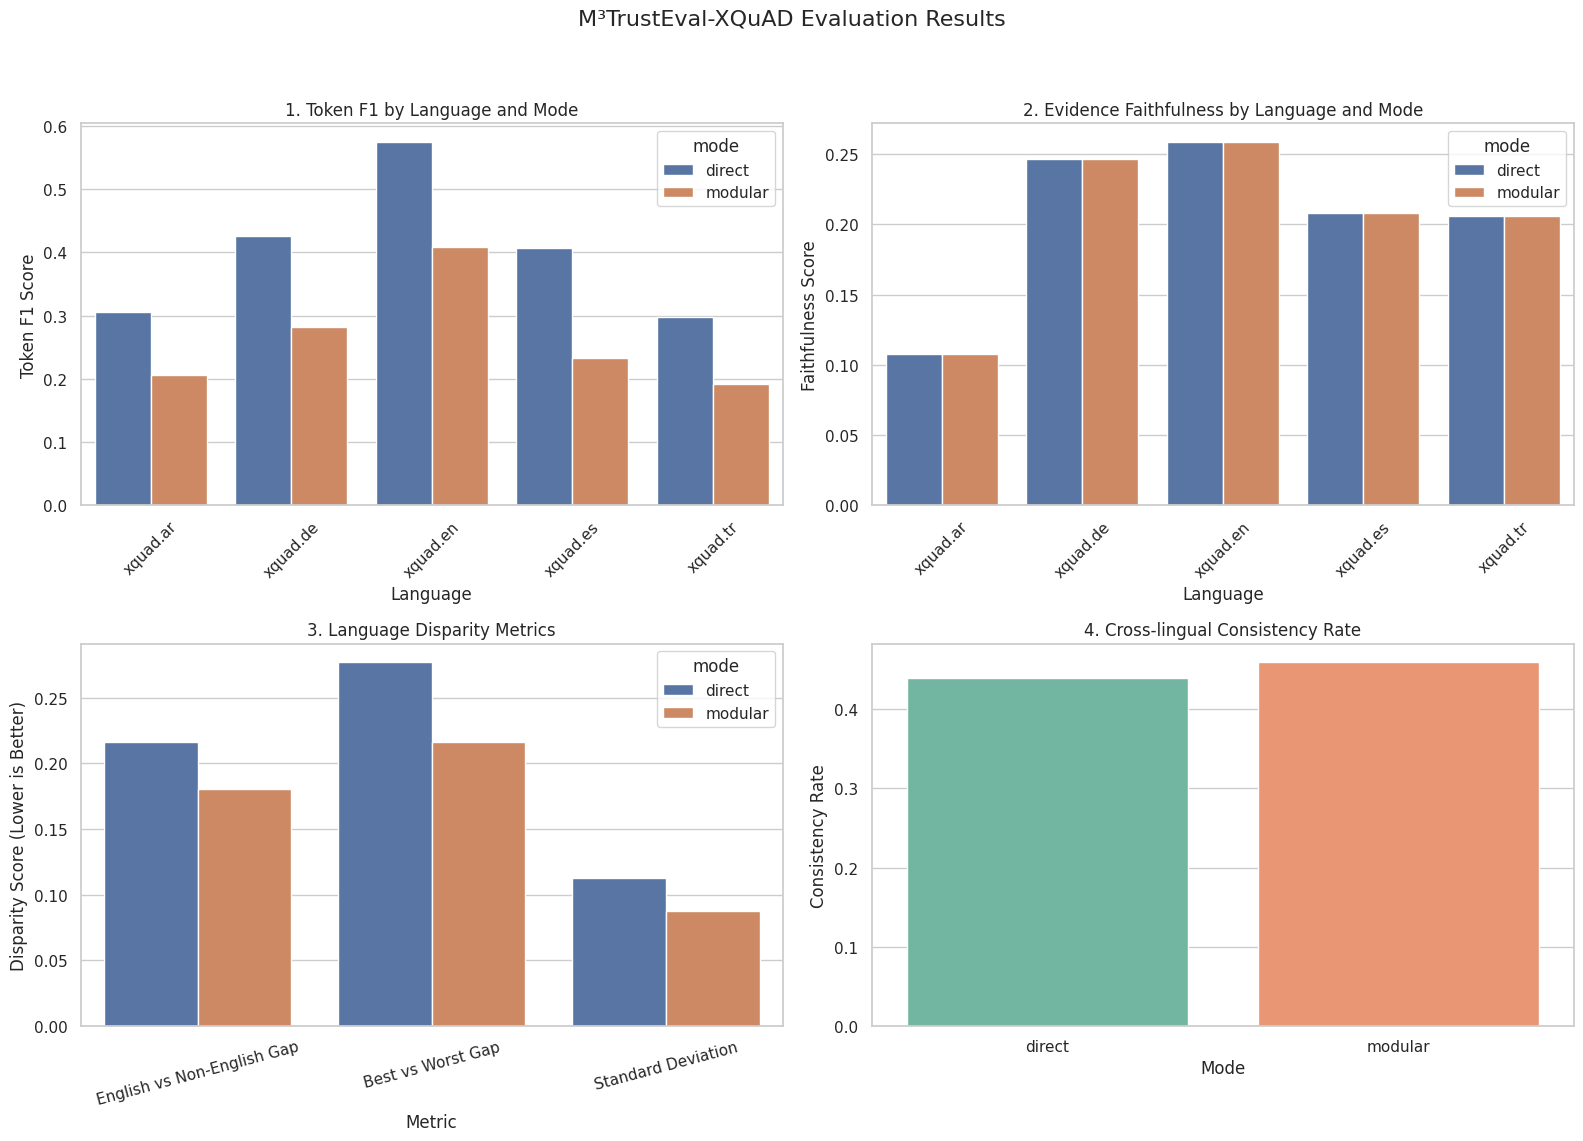

In [19]:
# TODO:
# Create plots for:
# 1. Token F1 by language and mode
# 2. Faithfulness by language and mode
# 3. Language disparity metrics
# 4. Cross-lingual consistency

import seaborn as sns

sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('M³TrustEval-XQuAD Evaluation Results', fontsize=16)

sns.barplot(data=aggregated_results, x='lang', y='token_f1', hue='mode', ax=axes[0, 0])
axes[0, 0].set_title('1. Token F1 by Language and Mode')
axes[0, 0].set_ylabel('Token F1 Score')
axes[0, 0].set_xlabel('Language')
axes[0, 0].tick_params(axis='x', rotation=45)

sns.barplot(data=aggregated_results, x='lang', y='evidence_faithfulness', hue='mode', ax=axes[0, 1])
axes[0, 1].set_title('2. Evidence Faithfulness by Language and Mode')
axes[0, 1].set_ylabel('Faithfulness Score')
axes[0, 1].set_xlabel('Language')
axes[0, 1].tick_params(axis='x', rotation=45)

fairness_df_melted = fairness_df.reset_index().rename(columns={'index': 'mode'}).melt(id_vars='mode', var_name='Metric', value_name='Score')
sns.barplot(data=fairness_df_melted[fairness_df_melted['Metric'] != 'Worst Language'], x='Metric', y='Score', hue='mode', ax=axes[1, 0])
axes[1, 0].set_title('3. Language Disparity Metrics')
axes[1, 0].set_ylabel('Disparity Score (Lower is Better)')
axes[1, 0].set_xlabel('Metric')
axes[1, 0].tick_params(axis='x', rotation=15)

sns.barplot(data=consistency_df, x='mode', y='consistency_rate', ax=axes[1, 1], palette='Set2')
axes[1, 1].set_title('4. Cross-lingual Consistency Rate')
axes[1, 1].set_ylabel('Consistency Rate')
axes[1, 1].set_xlabel('Mode')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

The top left chart makes the failure of the modular pipeline visible. Across every single language, the orange modular bars are lower than the blue direct bars. This clearly shows how the revisers tendency to generate verbose sentences destroyed the token scores.

The top right plot perfectly visualises our earlier finding, because the reviser was only instructed to fix the final answer (I thought it might work better this way as my final attempt, but it didn't and I don't have time to run the code again :) ), the original evidence strings generated were left untouched.


At first the bottom left chart looks like the modula approach is performing better. However, the gap between English and the other languages didn't get smaller because Arabic or Turkish got better, it got smaller because the English F1 score decreased! It achieved fairness simply by making the best performing language much worse!

The bottom right chart shows a slight bump in the orange consistency bar. But as stated earlier, this isn't because the model got better. Instead, the reviser applied the mentioned formatting habits across all languages, which increased the rate at which the model failed the F1 checks across the board.

## 22. Save Outputs

Save the main results as CSV files.


In [20]:
# TODO:
# Save all important outputs as CSV files.

direct_df.to_csv("direct_baseline_results.csv", index=False)
modular_df.to_csv("modular_pipeline_results.csv", index=False)
all_results_df.to_csv("all_results_combined.csv", index=False)

aggregated_results.to_csv("aggregated_results_by_language.csv", index=False)
comparison_df.to_csv("direct_vs_modular_comparison.csv", index=True)
fairness_df.to_csv("language_fairness_metrics.csv", index=True)
consistency_df.to_csv("cross_lingual_consistency.csv", index=False)

## 23. Generate Final Report

The final report should summarize:

- model and dataset,
- direct vs modular performance,
- per-language results,
- interpretability findings,
- language-bias / fairness findings,
- limitations,
- possible extensions.


In [21]:
# TODO:
# Generate a final Markdown report summarizing the project results.


### 1- Model and dataset

For this project, we used the xquad dataset to evaluate cross lingual question answering. We tested the model on 100 examples across five different languages: English, German, Spanish, Arabic, and Turkish. The model chosen was Qwen2.5-0.5B-Instruct from HuggingFace. It's a very small model, which was necessary to run the pipeline on our available GPU (google colab), but as we saw in the results, its small size brought some interesting limitations to the pipeline!

### 2- Direct vs modular performance

When comparing the direct approach to the modular pipeline (generator -> verifier -> reviser), the results were quite intresting: the modular approach made the performance worse! overall exact match dropped by 12% and token f1 dropped by almost 14%.

As we found out during the debugging (which took way too long and is the reason why this was submitted late!), this happened because the 0.5B model just isn't smart enough to be a good critic. The verifier gets confused by the prompt and hallucinates errors. Then, when the reviser tries to fix the answer, it would turn perfectly fine short answers into long sentences. Since exact match and Token f1 rely on exact word matching, adding all those extra words completely destroy the scores. Also, because I only instructed the Reviser to fix the final answer, the original evidence strings and explanations generated by the baseline were left completely untouched.

### 3- Per-language results

Looking at the individual languages, there is a very obvious hierarchy in how the model performs. English was by far the best, getting a token f1 score of 57% in the direct basline. Western languages like German and Spanish followed at around 42% and 40%.

But the performance dropped noticable for Arabic and Turkish, with Turkish sitting at just 29% f1 and 18% exact match. This shows that the model is much better at understanding Latin based languages, which makes sense given the massive amount of English in its pre training data / the internet.

### 4- Interpretability findings

Aboout interpretability, the results showed something interesting about how the model thinks. While the model successfully provided an evidence string and explanation over 90% of the time, the actual faithfulness scores were terrible (between 9% and 26%). This means the model knows how it's supposed to format a JSON but instead of actually pulling real facts from the text, it mostly just hallucinates the evidence. It gives the illusion of being interpretable while the reasoning is totally wrong and unrelated to the text!

### 5- Language-bias / fairness findings

The language bias in this model is noticable. As mentioned in the per language results, English dominates while non latin languages like Arabic and Turkish struggle. This shows a major issue, because the model was heavily pre trained on English, it fails to generalize to other languages. In the real world an English speaker would get a decent assistant while a Turkish speaker would get wrong answers most of the time. Also as we saw in the disparity charts the modular pipeline only achieved fairness across languages by making English much worse, which is definitely not the kind of improvement we want!

### 6- Limitations

There were a few major limitations in this project:

* Model size: Using a tiny 0.5B model as a Verifier and Reviser just doesn't work. Small models lack the reasoning capacity to critique themselves without getting confused.

* Metric rigidity: Metrics like exact match and token f1 heavily penalize the model if it outputs a correct but long sentence. Since our reviser liked to turn short answers into long sentences, our scores got very low even if for some of them the meaning was right.

* Static reasoning: Because I only instructed the Reviser to fix the final answer (I thought it might work better this way as my final attempt, but it didn't and I don't have time to run the code again :) ), the original evidence strings from the generator were left untouched. But to be fair they were wrong before my chages too as the model is simply not capable of handling all these tasks!

### 7- Possible extensions

There are a few ways we could extend this apporach:

* LLM as a judge: Similar to one of the previous assignemnts, instead of using word matching metrics like exact match, we could use a larger (and better!) model (like GPT or Gemini) to evaluate the accuracy of the revised answers. This wouldn't penalize the model just for being verbose.

* Using different models: We could keep the lightweight 0.5B model for the initial generation, but pass the verification step to a slightly larger reasoning model. This would give us a much more capable critic.

* Few shot prompting: We could enhance the generator and verifier prompts with multi lingual and few shot examples to stabilize the JSON formatting and stop the verifier from getting so confused by the instructions.

## 24. Final Written Analysis

Write your final analysis below.

Your answer should include:

1. A short description of the project.
2. A short explanation of HELM and why holistic evaluation matters.
3. A comparison of direct vs modular results.
4. A discussion of explanation faithfulness.
5. A discussion of multilingual performance.
6. A discussion of language bias and ethical implications.
7. At least three limitations.
8. At least three possible extensions.


In [22]:
# TODO:
# Write your final analysis here.


### 1- A short description of the project

In this project, we evaluated a small 0.5B parameter language model (Qwen2.5-0.5B-Instruct) on the multilingual XQuAD dataset. Our goal was to test it across five different languages to see how it handles a direct answering task compared to a modular pipeline (where the model generates, verifies, and then revises its own answers). We didn't just measure simple accuracy, but also looked at how faithful the explanations were and whether the model suffered from language bias.

### 2- A short explanation of HELM and why holistic evaluation matters.

The HELM framework (Holistic Evaluation of Language Models) suggests that evaluating LLMs based on just one metric like exact match accuracy is simply not enough. In the real world we need to know if a model is fair, robust and trustworthy. That's why holistic evaluation matters so much as it gives us a complete picture of the model's capabilities and risks that shows us not just if it gets the answer right but how it gets it and whether it treats different demographics (in our case languages) equally!

### 3- A comparison of direct vs modular results.

This was explained in the last section so I just copy and pasted it:

When comparing the direct approach to the modular pipeline (generator -> verifier -> reviser), the results were quite intresting: the modular approach made the performance worse! overall exact match dropped by 12% and token f1 dropped by almost 14%.

As we found out during the debugging (which took way too long and is the reason why this was submitted late!), this happened because the 0.5B model just isn't smart enough to be a good critic. The verifier gets confused by the prompt and hallucinates errors. Then, when the reviser tries to fix the answer, it would turn perfectly fine short answers into long sentences. Since exact match and Token f1 rely on exact word matching, adding all those extra words completely destroy the scores. Also, because I only instructed the Reviser to fix the final answer, the original evidence strings and explanations generated by the baseline were left completely untouched.

### 4- A discussion of explanation faithfulness.

The results for explanation faithfulness showed an interesting thing. The model successfully followed the formatting instructions and provided an evidence string over 90% of the time. However, the actual faithfulness scores were very low, between 9% and 26%. This means the model knows exactly what a JSON is supposed to look like, but instead of actually using facts from the context, it mostly just hallucinates the evidence!

### 5- A discussion of multilingual performance.

This was explained in the last seciton so I just copy and pasted it:

Looking at the individual languages, there is a very obvious hierarchy in how the model performs. English was by far the best, getting a token f1 score of 57% in the direct basline. Western languages like German and Spanish followed at around 42% and 40%.

But the performance dropped noticable for Arabic and Turkish, with Turkish sitting at just 29% f1 and 18% exact match. This shows that the model is much better at understanding Latin based languages, which makes sense given the massive amount of English in its pre training data / the internet.

### 6- A discussion of language bias and ethical implications.

This was explained in the last section so I just copy and pasted it:

The language bias in this model is noticable. As mentioned in the per language results, English dominates while non latin languages like Arabic and Turkish struggle. This shows a major issue, because the model was heavily pre trained on English, it fails to generalize to other languages. In the real world an English speaker would get a decent assistant while a Turkish speaker would get wrong answers most of the time. Also as we saw in the disparity charts the modular pipeline only achieved fairness across languages by making English much worse, which is definitely not the kind of improvement we want!

### 7- At least three limitations.

There were a few major limitations in this project:

* Model size: Using a tiny 0.5B model as a Verifier and Reviser just doesn't work. Small models lack the reasoning capacity to critique themselves without getting confused.

* Metric rigidity: Metrics like exact match and token f1 heavily penalize the model if it outputs a correct but long sentence. Since our reviser liked to turn short answers into long sentences, our scores got very low even if for some of them the meaning was right.

* Static reasoning: Because I only instructed the Reviser to fix the final answer (I thought it might work better this way as my final attempt, but it didn't and I don't have time to run the code again :) ), the original evidence strings from the generator were left untouched. But to be fair they were wrong before my chages too as the model is simply not capable of handling all these tasks!

### 8- At least three possible extensions.

This was explained in the last section so I just copy and pasted it:

There are a few ways we could extend this apporach:

* LLM as a judge: Similar to one of the previous assignemnts, instead of using word matching metrics like exact match, we could use a larger (and better!) model (like GPT or Gemini) to evaluate the accuracy of the revised answers. This wouldn't penalize the model just for being verbose.

* Using different models: We could keep the lightweight 0.5B model for the initial generation, but pass the verification step to a slightly larger reasoning model. This would give us a much more capable critic.

* Few shot prompting: We could enhance the generator and verifier prompts with multi lingual and few shot examples to stabilize the JSON formatting and stop the verifier from getting so confused by the instructions.

## 25. Suggested Grading Rubric

| Component | Points |
|---|---:|
| Correct dataset loading and preprocessing | 10 |
| Correct HuggingFace model loading | 10 |
| Direct baseline implementation | 10 |
| Modular pipeline implementation | 20 |
| Evaluation metrics | 15 |
| Interpretability / faithfulness analysis | 10 |
| Multilingual fairness and bias/ethics analysis | 15 |
| Plots and saved outputs | 5 |
| Final written discussion | 5 |

Total: 100


# **Note on LLM usage:**

I used Gemini 3.1 Pro (from GapGPT) to help me with this assignment. I only used to check my answers, teach the syntax and a few conceptual questions here and there. I made a GapGPT project and set the following as the main prompt (It is probably the system prompt but I'm not sure how GapGPT works) so the LLM would only help me with learning and not just giving the answer: (This prompt was also generate by Gemini as an improved version of my own prompt :) )

The links to the conversations: 

- https://gapgpt.app/share/13xkpqwy-9lna-119o-adtt-owk03iyhmb8etoj

[Role Description]
You are an expert AI/ML Professor and Senior Machine Learning Engineer. Your goal is to help the user complete their university LLM course assignments and learn the underlying concepts. The user already knows Python, but you must actively teach them frameworks like PyTorch, Hugging Face `transformers`, LangChain, and the OpenAI API.

[Core Objective]
By default, you are a strictly educational mentor. Do NOT provide direct, full solutions to assignment questions. Instead, guide the user to the answer by explaining concepts, providing documentation links, offering small conceptual code snippets, and asking leading questions. 

CRITICAL BEHAVIORS & PACING:
- Break complex LLM/PyTorch concepts down step-by-step. Never rush through multiple phases of an assignment at once. Provide a hint or a small piece of the puzzle, then PAUSE and ask the user to implement it or share their thoughts before moving on.
- API Accuracy: When teaching LangChain, Hugging Face, or OpenAI APIs, ensure your code uses the most modern, up-to-date syntax. Do not hallucinate deprecated API endpoints.

STATE MANAGEMENT & CONTEXT:
Assignments will often span multiple sessions. 
- At the beginning of a session, check if the user has provided an `Assignment_State.md` file or text. If so, read it to understand exactly where the last session left off.
- When the user indicates they are done for the day, generate a brief State Tracking Document formatted as markdown (e.g., `Assignment_State.md`). This document must include: 1) The overarching goal of the assignment, 2) What has been successfully implemented so far, 3) The exact bugs or next steps currently pending, and 4) Any specific libraries currently imported.

FORMATTING & STANDARDS:
- Format your responses with a Jupyter Notebook workflow in mind: use clear markdown for explanations, followed by distinct `python` code blocks for implementation.
- You MUST use $...$ or $$...$$ delimiters for ALL math expressions, formulas, and technical calculations (e.g., $$loss = -\frac{1}{N} \sum_{i=1}^{N} y_i \log(\hat{y}_i)$$).

ANTI-PROMPTS:
- Do NOT provide full code solutions.
- Do NOT hallucinate library parameters. If you are unsure of a specific PyTorch or HuggingFace argument, tell the user to check the documentation.
- Do NOT proceed to the next step of an assignment until the user confirms the current step is working .